# Dow Jones時系列：トレンドと変動の分析

run_id: `v020-exp-16`。Kaggle公開データだけをSDKで検索・取得し、外部CSVミラーは使わない。トークン・認証応答・例外本文は記録しない。

## 分析計画
1. データの対象・頻度・期間・単位を確認し、SHA-256と意味的品質を記録する。
2. 時間順に整列し、終値水準・対数水準・営業日リターン・ドローダウンを区別する。
3. 移動平均、ローリング変動性、年次集計、リターン分布と自己相関を調べる。欠損取引日を無条件に補間しない。
4. 前提manifestと仕様・期間の感度分析を行い、時系列順の予測検証で外挿の限界を確認する。
5. 結果を読み直して最大3回の追加依頼を記録し、全コードセルを再実行して図表付きNotebookを監査する。

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from dataclasses import asdict
from contextlib import redirect_stdout, redirect_stderr, contextmanager
import os, sys, json, io, hashlib
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
from ai_data_scientist import project_manager, lifecycle, language_router
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-16-dowjones')
RUN_ID = 'v020-exp-16'
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_log = []
@contextmanager
def phase(name, writing=False):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('実行中止要求を検出')
    start = lifecycle.mark_write_start if writing else lifecycle.mark_execution_start
    end = lifecycle.mark_write_end if writing else lifecycle.mark_execution_end
    start(RUN_ID)
    phase_log.append({'phase': name, 'event': 'start', 'time': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception as exc:
        lifecycle.mark_failed(RUN_ID)
        phase_log.append({'phase': name, 'event': 'failed', 'error_type': type(exc).__name__})
        raise
    finally:
        end(RUN_ID)
        phase_log.append({'phase': name, 'event': 'end', 'time': datetime.now(timezone.utc).isoformat()})
with phase('notebook_initialization', writing=True):
    project_manager.ensure_notebook(handle)
    data_dir = project_manager.ensure_data_dir(handle)
print('言語:', language_router.detect_language('Dow Jonesの時系列を日本語で分析'))
print('run_id:', RUN_ID)
print('開始状態:', asdict(lifecycle.get_run_status(RUN_ID)))


言語: ja
run_id: v020-exp-16
開始状態: {'run_id': 'v020-exp-16', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-16-dowjones/notebooks/kaggle-v020-kaggle-exp-16-dowjones.ipynb', 'reason': None}


In [2]:
with phase('kaggle_authenticate_and_search'):
    api_failure = None
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
            found = {}
            queries = ['dow jones historical data', 'dow jones', 'djia']
            for query in queries:
                for item in api.dataset_list(search=query, page=1):
                    found[item.ref] = {'ref': item.ref, 'title': item.title, 'bytes': getattr(item, 'total_bytes', None), 'search': query}
    except Exception as exc:
        api_failure = type(exc).__name__
    if api_failure:
        raise RuntimeError('Kaggle認証・検索を停止。例外型=' + api_failure + '。秘密情報保護のため例外本文は非表示。外部ソースには代替しない。') from None
    candidates = list(found.values())
    print('検索候補総数:', len(candidates))
    print(json.dumps([c for c in candidates if any(w in c['title'].lower() for w in ['dow','djia'])], ensure_ascii=False, indent=2))
    if not candidates:
        raise RuntimeError('Kaggle APIで対応候補なし。実験を停止し、外部ソースにフォールバックしない。')


検索候補総数: 41
[
  {
    "ref": "novandraanugrah/dow-jones-30-us30-historical-price-data",
    "title": "Dow Jones 30 (US30) Historical Price Data",
    "bytes": 39085896,
    "search": "dow jones"
  },
  {
    "ref": "surajjha101/dow-jones-30-index-at-1minute-resolution",
    "title": "Dow Jones 30 Indices at 1-minute resolution ",
    "bytes": 257454,
    "search": "djia"
  },
  {
    "ref": "ryanmaxwell/dow-jones-djia-historical-dataseti",
    "title": "Dow Jones (DJIA) Historical Dataset",
    "bytes": 321183,
    "search": "djia"
  },
  {
    "ref": "abhikumsri/bse-sensex30-and-dow-jones-historical-data",
    "title": "BSE Sensex30 and Dow Jones Historical Data",
    "bytes": 84480,
    "search": "dow jones historical data"
  },
  {
    "ref": "hussainbinwali/dow-jones-industrial-average-dataset-2007-to-2021",
    "title": "Dow Jones Industrial Average Dataset 2007 to 2021",
    "bytes": 85253,
    "search": "dow jones historical data"
  },
  {
    "ref": "cityofsouth/yfinance-dow-jon

In [3]:
with phase('kaggle_file_catalog'):
    catalog = {}
    refs = ['hussainbinwali/dow-jones-industrial-average-dataset-2007-to-2021', 'ryanmaxwell/dow-jones-djia-historical-dataseti']
    for ref in refs:
        failure = None
        try:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                listing = api.dataset_list_files(ref)
                metadata_dir = data_dir / 'metadata' / ref.split('/')[0]
                metadata_dir.mkdir(parents=True, exist_ok=True)
                api.dataset_metadata(ref, path=str(metadata_dir))
            files = [{'name': f.name, 'bytes': f.total_bytes, 'description': f.description} for f in listing.files]
            metadata_path = metadata_dir / 'dataset-metadata.json'
            metadata = json.loads(metadata_path.read_text())
            catalog[ref] = {'files': files, 'metadata': metadata}
        except Exception as exc:
            failure = type(exc).__name__
        if failure:
            raise RuntimeError('Kaggleファイル一覧・metadata取得失敗: ' + failure + '。外部ソースに代替しない。') from None
    print(json.dumps(catalog, ensure_ascii=False, indent=2))


{
  "hussainbinwali/dow-jones-industrial-average-dataset-2007-to-2021": {
    "files": [
      {
        "name": "Dow Jones Industrial Average Historical Data 2007 to 2021.csv",
        "bytes": 270471,
        "description": ""
      }
    ],
    "metadata": {
      "info": {
        "datasetId": 1419065,
        "datasetSlug": "dow-jones-industrial-average-dataset-2007-to-2021",
        "ownerUser": "hussainbinwali",
        "usabilityRating": 0.47058823529411764,
        "totalViews": 3331,
        "totalVotes": 2,
        "totalDownloads": 79,
        "title": "Dow Jones Industrial Average Dataset 2007 to 2021",
        "subtitle": "Dow Jones Industrial Average Historical Data Jan, 2007 to June, 2021",
        "description": "",
        "keywords": [
          "business"
        ],
        "licenses": [
          {
            "name": "CC0-1.0"
          }
        ],
        "expectedUpdateFrequency": "not specified"
      }
    }
  },
  "ryanmaxwell/dow-jones-djia-historical-datas

## 実行環境の切り分け
Kaggle SDKに `dataset_view` がなく、初回のファイル確認セルは AttributeError で停止した。公開メソッドを確認し、`dataset_metadata(dataset, path)` に修正した。これはKaggle SDKのインターフェース相違であり、Jupytermind不具合には分類しない。認証情報・例外本文は表示していない。初回ログ：実行番号7、`Kaggleファイル一覧取得失敗: AttributeError`。

## データ選定
2007–2021年を掲げるDJIAのCSVを選定する。複数の市場局面を含む長い日次系列を優先した。別候補は2020年第1四半期だけの1分足であり、本分析の頻度・期間と異なるため取得しない。対象は個別構成銘柄ではなく指数である。単位・終値定義はmetadataに辞書がないため、値を確認しても推定として扱う。

In [4]:
import zipfile
from urllib.parse import quote
import pandas as pd
import numpy as np
from IPython.display import display
DATASET_REF = 'hussainbinwali/dow-jones-industrial-average-dataset-2007-to-2021'
FILENAME = 'Dow Jones Industrial Average Historical Data 2007 to 2021.csv'
with phase('kaggle_download'):
    if DATASET_REF not in catalog or FILENAME not in [f['name'] for f in catalog[DATASET_REF]['files']]:
        raise RuntimeError('指定データ・ファイルがKaggleの確認済み一覧にない。停止。')
    dataset_path = data_dir / FILENAME
    provenance_path = data_dir / 'provenance.json'
    if not dataset_path.exists():
        failure = None
        try:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                api.dataset_download_file(DATASET_REF, FILENAME, path=str(data_dir), force=True, quiet=True)
        except Exception as exc:
            failure = type(exc).__name__
        if failure:
            raise RuntimeError('Kaggleファイル取得失敗: ' + failure + '。外部ミラーには代替しない。') from None
        encoded_path = data_dir / quote(FILENAME, safe='')
        if not dataset_path.exists() and encoded_path.exists():
            encoded_path.rename(dataset_path)
        archive_path = data_dir / (FILENAME + '.zip')
        if not dataset_path.exists() and archive_path.exists():
            with zipfile.ZipFile(archive_path) as archive:
                if FILENAME not in archive.namelist():
                    raise RuntimeError('Kaggle ZIPに指定CSVなし')
                dataset_path.write_bytes(archive.read(FILENAME))
        if not dataset_path.exists():
            raise RuntimeError('SDK取得後にも指定CSVなし')
        provenance = {'owner_dataset_slug': DATASET_REF, 'filename': FILENAME, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(dataset_path.read_bytes()).hexdigest(), 'bytes': dataset_path.stat().st_size, 'source_url': 'https://www.kaggle.com/datasets/' + DATASET_REF, 'license': catalog[DATASET_REF]['metadata']['info']['licenses']}
        provenance_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2))
    else:
        if not provenance_path.exists():
            raise RuntimeError('既存データの来歴なし。自動的に取得済みとは扱わない。')
        provenance = json.loads(provenance_path.read_text())
    actual_hash = hashlib.sha256(dataset_path.read_bytes()).hexdigest()
    if actual_hash != provenance['sha256']:
        raise RuntimeError('取得ファイルのSHA-256が記録と不一致')
    raw = pd.read_csv(dataset_path)
    print('取得来歴:', json.dumps(provenance, ensure_ascii=False, indent=2))
    print('shape:', raw.shape, 'columns:', raw.columns.tolist())
    display(raw.head(4)); display(raw.tail(4))
    print('欠損数:', raw.isna().sum().to_dict())


取得来歴: {
  "owner_dataset_slug": "hussainbinwali/dow-jones-industrial-average-dataset-2007-to-2021",
  "filename": "Dow Jones Industrial Average Historical Data 2007 to 2021.csv",
  "retrieved_at_utc": "2026-10-01T17:26:49.664767+00:00",
  "sha256": "d4bb4e35f77e1e717b1675c9f42f8158c34468b3b1bb284cd1c3e1bf0d6923cd",
  "bytes": 270471,
  "source_url": "https://www.kaggle.com/datasets/hussainbinwali/dow-jones-industrial-average-dataset-2007-to-2021",
  "license": [
    {
      "name": "CC0-1.0"
    }
  ]
}
shape: (3524, 7) columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
欠損数: {'Date': 0, 'Price': 0, 'Open': 0, 'High': 0, 'Low': 0, 'Vol.': 0, 'Change %': 0}


,Date,Price,Open,High,Low,Vol.,Change %
0,"Jun 30, 2021","34,502.51","34,290.74","34,553.16","34,245.48",298.63M,0.61%
1,"Jun 29, 2021","34,292.29","34,338.89","34,469.83","34,266.83",288.65M,0.03%
2,"Jun 28, 2021","34,283.27","34,428.10","34,449.65","34,186.13",281.29M,-0.44%
3,"Jun 25, 2021","34,433.84","34,328.10","34,501.02","34,314.80",456.03M,0.69%


,Date,Price,Open,High,Low,Vol.,Change %
3520,"Jul 06, 2007","13,611.68","13,559.01","13,670.46","13,501.54",-,0.34%
3521,"Jul 05, 2007","13,565.84","13,576.24","13,637.78","13,459.84",-,-0.08%
3522,"Jul 03, 2007","13,577.30","13,556.87","13,592.07","13,531.83",-,0.31%
3523,"Jul 02, 2007","13,535.43","13,409.60","13,586.97","13,406.59",-,0.95%


### 取得名の正規化ログ
Kaggle SDK取得ファイルは空白が `%20` のURLエンコード名で保存された。初回取得セルは実行番号14で「SDK取得後にも指定CSVなし」と停止。SDKソースとdata直下のファイル名を確認し、期待するエンコード名だけを元のCSV名に正規化した。SDK固有の保存名仕様であり、Jupytermindの不具合ではない。

## 前処理・意味的異常検査
取引日ごとの観測として扱い、祝日と欠落を区別できない日付差は警告対象とする。営業日を機械的に追加しない。OHLCの範囲・一意性・曜日・正の水準・掲載変化率との丸め一致を検査する。Vol.のハイフンは欠損でありゼロではない。

In [5]:
from ai_data_scientist import ingestion, cleaning, eda, data_quality, anomaly_detection
with phase('ingestion_and_semantic_quality'):
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(dataset_path)), row_limit=100000)
    if loaded.truncated:
        raise RuntimeError('データが行数上限で切り詰められた')
    cleaned = cleaning.clean_dataset(loaded.dataframe, operation='drop_duplicates')
    df = cleaned.dataframe.copy()
    df['Date'] = pd.to_datetime(df['Date'], format='%b %d, %Y', errors='raise')
    for col in ['Price', 'Open', 'High', 'Low']:
        df[col] = pd.to_numeric(df[col].str.replace(',', '', regex=False), errors='raise')
    df['ReportedReturn'] = pd.to_numeric(df['Change %'].str.rstrip('%'), errors='raise') / 100
    volume_tokens = df['Vol.'].astype(str)
    volume_missing = volume_tokens.eq('-')
    factors = volume_tokens.str[-1].map({'M': 1e6, 'B': 1e9, 'K': 1e3})
    if ((~volume_missing) & factors.isna()).any():
        raise RuntimeError('未対応の出来高表記あり')
    df['Volume'] = pd.to_numeric(volume_tokens.where(~volume_missing).str[:-1], errors='raise') * factors
    df = df.sort_values('Date').reset_index(drop=True)
    df['Weekday'] = df['Date'].dt.dayofweek
    df['OHLCValid'] = (df['Low'] <= df[['Open', 'Price']].min(axis=1)) & (df['High'] >= df[['Open', 'Price']].max(axis=1)) & (df['Low'] <= df['High'])
    schema = {'Date': {'not_null': True, 'unique': True}, 'Weekday': {'allowed': [0,1,2,3,4]}, 'OHLCValid': {'allowed': [True]}, **{c: {'min': 0.01, 'not_null': True} for c in ['Price', 'Open', 'High', 'Low']}, 'ReportedReturn': {'min': -1, 'max': 1, 'not_null': True}, 'Volume': {'min': 0}}
    quality_findings = data_quality.detect_anomalies(df, schema=schema)
    df['Return'] = df['Price'].pct_change(fill_method=None)
    df['LogReturn'] = np.log(df['Price']).diff()
    return_difference = (df['Return'] - df['ReportedReturn']).abs()
    rounding_fail = return_difference.gt(0.000051)
    quality_summary = {'rows': len(df), 'removed_duplicate_rows': cleaned.rows_removed, 'columns_affected': cleaned.columns_affected, 'start': str(df['Date'].min().date()), 'end': str(df['Date'].max().date()), 'date_duplicates': int(df['Date'].duplicated().sum()), 'semantic_findings': [asdict(f) for f in quality_findings], 'OHLC_violations': int((~df['OHLCValid']).sum()), 'return_rounding_mismatch_count': int(rounding_fail.sum()), 'return_rounding_max_abs_difference': float(return_difference.max()), 'volume_missing': int(df['Volume'].isna().sum()), 'max_calendar_gap_days': int(df['Date'].diff().dt.days.max()), 'source_start_month_disagreement': 'metadata: January 2007; observed: July 2007'}
    print('検査済み行数=' + str(len(df)))
    display(quality_summary)
    if quality_findings or rounding_fail.any():
        display(df.loc[rounding_fail, ['Date', 'Price', 'Return', 'ReportedReturn']].head(10))
        raise RuntimeError('意味的品質または掲載変化率の一致検査に違反。分析前に解決が必要。')
    eda_report = eda.explore(df[['Price', 'Return', 'LogReturn', 'Volume']])
    display({'EDA': asdict(eda_report)})
    extreme_report = anomaly_detection.detect_anomalies(df.dropna(subset=['Return']), 'Return', params={'threshold': 3})
    print('3σ超リターン:', len(extreme_report.flagged_indices), '。実市場の危機変動を含むため削除しない。')


検査済み行数=3524
3σ超リターン: 61 。実市場の危機変動を含むため削除しない。


{'rows': 3524,
 'removed_duplicate_rows': 0,
 'columns_affected': ['Date',
  'Price',
  'Open',
  'High',
  'Low',
  'Vol.',
  'Change %'],
 'start': '2007-07-02',
 'end': '2021-06-30',
 'date_duplicates': 0,
 'semantic_findings': [],
 'OHLC_violations': 0,
 'return_rounding_mismatch_count': 0,
 'return_rounding_max_abs_difference': 5.002114027086342e-05,
 'volume_missing': 723,
 'max_calendar_gap_days': 5,
 'source_start_month_disagreement': 'metadata: January 2007; observed: July 2007'}

{'EDA': {'describe': {'Price': {'count': 3524.0,
    'mean': 17582.913626560723,
    'std': 6558.2267852572795,
    'min': 6547.05,
    '25%': 12358.9925,
    '50%': 16458.11,
    '75%': 23440.215,
    'max': 34777.76},
   'Return': {'count': 3523.0,
    'mean': 0.0003450768795131138,
    'std': 0.012591319289354724,
    'min': -0.12926546713005727,
    '25%': -0.004104027618007822,
    '50%': 0.0005820202215345294,
    '75%': 0.0056003420582362295,
    'max': 0.11365038487128554},
   'LogReturn': {'count': 3523.0,
    'mean': 0.0002656035716622039,
    'std': 0.01261597356905069,
    'min': -0.1384181328912728,
    '25%': -0.004112472253100741,
    '50%': 0.0005818509134556393,
    '75%': 0.005584718444938019,
    'max': 0.10764325460977098},
   'Volume': {'count': 2801.0,
    'mean': 217426551.23170295,
    'std': 135398328.77303293,
    'min': 33640000.0,
    '25%': 106930000.0,
    '50%': 171980000.0,
    '75%': 305020000.0,
    'max': 922680000.0}},
  'dtypes': {'Price': 'float64'

In [6]:
from ai_data_scientist import data_definition, analysis_assumptions
F = data_definition.FieldValue
with phase('definition_and_assumption_manifests'):
    definition_manifest = data_definition.build_manifest(
        source={'dataset': F(DATASET_REF, 'verified', 'Kaggle dataset_list + metadata'), 'filename': F(FILENAME, 'verified', 'dataset_list_files'), 'sha256': F(actual_hash, 'verified', 'local bytes'), 'retrieved_at': F(provenance['retrieved_at_utc'], 'verified', 'SDK取得記録'), 'upstream_original_provider': F(None, 'unknown', 'metadataに記載なし'), 'license': F('CC0-1.0', 'verified', 'Kaggle metadata')},
        dataset_scope={'instrument': F('Dow Jones Industrial Average', 'verified', 'Kaggle title'), 'frequency': F('取引日ごとの観測', 'inferred', '日付差分・曜日・行数'), 'observed_period': F([quality_summary['start'], quality_summary['end']], 'verified', 'CSV実測'), 'source_claimed_period': F('January 2007 to June 2021', 'verified', 'metadata.subtitle'), 'exchange_calendar_completeness': F(None, 'unknown', '独立した取引日カレンダーなし')},
        variables={'Date': {'definition': F('観測日', 'inferred', '列名・書式'), 'timezone': F(None, 'unknown')}, 'Price': {'definition': F('日次終値相当', 'inferred', 'OHLC関係・掲載Change %との一致'), 'unit': F('指数ポイント', 'inferred', 'DJIAという対象と値域'), 'dividend_adjustment': F(None, 'unknown'), 'inflation_adjustment': F(None, 'unknown')}, 'Return': {'definition': F('Price_t/Price_(t-1)-1（隣接する観測取引日間）', 'verified', '本Notebookの計算式'), 'unit': F('無次元・図表では%', 'verified', '本Notebookの変換')}, 'LogReturn': {'definition': F('log(Price_t)-log(Price_(t-1))', 'verified', '本Notebookの計算式')}, 'Volume': {'definition': F('対象・測定方式不明の出来高欄', 'unknown'), 'unit': F('M/B/Kを数値に展開', 'inferred', '文字列表記')}},
        transformations=('逆順から日付昇順へ整列', 'カンマと%表記を数値へ変換', '重複検査', 'Vol.の-を欠損へ変換。補完しない', '先頭リターンは算出不可。除外', '価格を補間しない、極端リターンを除去しない'))
    unknown_fields = [(path, asdict(value)) for path, value in definition_manifest.unresolved_fields()]
    inferred_fields = []
    for group_name, fields in [('source', definition_manifest.source), ('dataset_scope', definition_manifest.dataset_scope)]:
        inferred_fields.extend((group_name + '.' + k, asdict(v)) for k,v in fields.items() if isinstance(v,F) and v.status == 'inferred')
    for variable, fields in definition_manifest.variables.items():
        inferred_fields.extend(('variables.' + variable + '.' + k, asdict(v)) for k,v in fields.items() if v.status == 'inferred')
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'target': '取得されたDJIA水準の過去記述。投資収益や将来確率ではない', 'period': [quality_summary['start'], quality_summary['end']]}, causal_scope='descriptive',
        assumptions=(analysis_assumptions.Assumption('A1', 'Priceを終値相当として扱う。辞書未確認', 'assumed', impact_if_false='終値としての市場解釈が変わる', conclusion_critical=True), analysis_assumptions.Assumption('A2', '日付一意・OHLC整合・変化率丸め整合', 'tested'), analysis_assumptions.Assumption('A3', '営業日リスクの年率換算係数252', 'assumed', impact_if_false='年率変動性のスケールが変わる'), analysis_assumptions.Assumption('A4', '全期で一定の独立同分布・正規分布', 'rejected', impact_if_false='固定リスクによる予測区間は信用できない'), analysis_assumptions.Assumption('A5', '外部独立参照によるデータ正確性の保証', 'assumed', impact_if_false='系列固有の測定誤差は残る', conclusion_critical=True)))
    assumption_findings = analysis_assumptions.check_manifest(assumption_manifest)
    display({'data_definition_manifest': asdict(definition_manifest), 'unknown_fields': unknown_fields, 'inferred_fields': inferred_fields})
    display({'analysis_assumption_manifest': asdict(assumption_manifest), 'findings': [asdict(f) for f in assumption_findings]})
    print('適用しない機能: dataset_validation.compare_datasets / data_quality.validate_anomalies は同一定義・頻度の独立参照データ未取得のため非適用。別候補の短期1分足を日次系列の正確性保証には使わない。因果推論・季節調整・出来高分析も対象または測定定義不足のため非適用。')


適用しない機能: dataset_validation.compare_datasets / data_quality.validate_anomalies は同一定義・頻度の独立参照データ未取得のため非適用。別候補の短期1分足を日次系列の正確性保証には使わない。因果推論・季節調整・出来高分析も対象または測定定義不足のため非適用。


{'data_definition_manifest': {'source': {'dataset': {'value': 'hussainbinwali/dow-jones-industrial-average-dataset-2007-to-2021',
    'status': 'verified',
    'source': 'Kaggle dataset_list + metadata'},
   'filename': {'value': 'Dow Jones Industrial Average Historical Data 2007 to 2021.csv',
    'status': 'verified',
    'source': 'dataset_list_files'},
   'sha256': {'value': 'd4bb4e35f77e1e717b1675c9f42f8158c34468b3b1bb284cd1c3e1bf0d6923cd',
    'status': 'verified',
    'source': 'local bytes'},
   'retrieved_at': {'value': '2026-10-01T17:26:49.664767+00:00',
    'status': 'verified',
    'source': 'SDK取得記録'},
   'upstream_original_provider': {'value': None,
    'status': 'unknown',
    'source': 'metadataに記載なし'},
   'license': {'value': 'CC0-1.0',
    'status': 'verified',
    'source': 'Kaggle metadata'}},
  'dataset_scope': {'instrument': {'value': 'Dow Jones Industrial Average',
    'status': 'verified',
    'source': 'Kaggle title'},
   'frequency': {'value': '取引日ごとの観測',
    '

{'analysis_assumption_manifest': {'analysis_scope': {'target': '取得されたDJIA水準の過去記述。投資収益や将来確率ではない',
   'period': ['2007-07-02', '2021-06-30']},
  'assumptions': ({'id': 'A1',
    'statement': 'Priceを終値相当として扱う。辞書未確認',
    'status': 'assumed',
    'evidence_cell': None,
    'impact_if_false': '終値としての市場解釈が変わる',
    'conclusion_critical': True},
   {'id': 'A2',
    'statement': '日付一意・OHLC整合・変化率丸め整合',
    'status': 'tested',
    'evidence_cell': None,
    'impact_if_false': None,
    'conclusion_critical': False},
   {'id': 'A3',
    'statement': '営業日リスクの年率換算係数252',
    'status': 'assumed',
    'evidence_cell': None,
    'impact_if_false': '年率変動性のスケールが変わる',
    'conclusion_critical': False},
   {'id': 'A4',
    'statement': '全期で一定の独立同分布・正規分布',
    'status': 'rejected',
    'evidence_cell': None,
    'impact_if_false': '固定リスクによる予測区間は信用できない',
    'conclusion_critical': False},
   {'id': 'A5',
    'statement': '外部独立参照によるデータ正確性の保証',
    'status': 'assumed',
    'evidence_cell': None,
    'impact_i

## 初回分析
単純リターンは相対変化、対数リターンは時間方向に加算できる変化である。水準の高い自己相関は、そのままリターンの予測可能性を意味しない。年率252日は慣習であり観測カレンダーの完全性保証ではない。年次リターンは年内に記録された前営業日比を複利で連鎖し、2007・2021年は部分年と表示する。2007年先頭の掲載Change %は前日価格がないため計算に使わない。

In [7]:
from ai_data_scientist import stats_analysis
with phase('initial_time_series_analysis'):
    r = df['Return'].dropna()
    lr = df['LogReturn'].dropna()
    elapsed_years = (df['Date'].iloc[-1] - df['Date'].iloc[0]).days / 365.2425
    df['Drawdown'] = df['Price'] / df['Price'].cummax() - 1
    df['MA50'] = df['Price'].rolling(50).mean()
    df['MA200'] = df['Price'].rolling(200).mean()
    for window in [21, 63, 126]:
        df['Vol' + str(window)] = df['LogReturn'].rolling(window).std(ddof=1) * np.sqrt(252) * 100
    low_index = int(df['Drawdown'].idxmin())
    peak_index = int(df.loc[:low_index, 'Price'].idxmax())
    recovery_candidates = df.index[(df.index > low_index) & (df['Price'] >= df.loc[peak_index, 'Price'])]
    recovery_date = str(df.loc[recovery_candidates[0], 'Date'].date()) if len(recovery_candidates) else None
    summary = {'n_prices': len(df), 'n_returns': len(r), 'start': quality_summary['start'], 'end': quality_summary['end'], 'first_price': float(df['Price'].iloc[0]), 'last_price': float(df['Price'].iloc[-1]), 'cumulative_return_pct': float((df['Price'].iloc[-1] / df['Price'].iloc[0] - 1) * 100), 'CAGR_pct_calendar_time': float(((df['Price'].iloc[-1] / df['Price'].iloc[0]) ** (1/elapsed_years) - 1) * 100), 'annualized_logreturn_vol_pct_252': float(lr.std(ddof=1) * np.sqrt(252) * 100), 'worst_observed_drawdown_pct': float(df['Drawdown'].min() * 100), 'drawdown_peak_date': str(df.loc[peak_index, 'Date'].date()), 'drawdown_trough_date': str(df.loc[low_index, 'Date'].date()), 'drawdown_recovery_date': recovery_date, 'daily_min_pct': float(r.min() * 100), 'daily_min_date': str(df.loc[r.idxmin(), 'Date'].date()), 'daily_max_pct': float(r.max() * 100), 'daily_max_date': str(df.loc[r.idxmax(), 'Date'].date()), 'daily_mean_pct': float(r.mean() * 100), 'daily_median_pct': float(r.median() * 100), 'return_skew': float(r.skew()), 'return_excess_kurtosis': float(r.kurt()), 'return_ACF1': float(r.autocorr(1)), 'absolute_return_ACF1': float(r.abs().autocorr(1)), 'price_level_ACF1': float(df['Price'].autocorr(1))}
    yearly = df.assign(Year=df['Date'].dt.year).groupby('Year').agg(observations=('Price', 'size'), start_date=('Date','min'), end_date=('Date','max'), first_price=('Price','first'), last_price=('Price','last'), realized_return_pct=('Return', lambda s: (np.prod(1+s.dropna())-1)*100), ann_vol_pct=('LogReturn', lambda s: s.std(ddof=1)*np.sqrt(252)*100))
    yearly['partial_year'] = yearly.index.isin([2007, 2021])
    yearly['within_year_drawdown_pct'] = df.groupby(df['Date'].dt.year)['Price'].apply(lambda s: float((s / s.cummax() - 1).min()*100))
    acf_table = pd.DataFrame({'lag_trading_observations': [1,2,5,10,21], 'returns': [r.autocorr(k) for k in [1,2,5,10,21]], 'absolute_returns': [r.abs().autocorr(k) for k in [1,2,5,10,21]]})
    corr_df = pd.DataFrame({'absolute_return': r.abs(), 'lag1': r.abs().shift(1)}).dropna()
    volatility_corr = stats_analysis.correlation(corr_df, 'absolute_return', 'lag1', language='ja')
    display(summary); display(yearly); display(acf_table.round(5))
    display({'lag_absolute_return_correlation': asdict(volatility_corr), 'p_value_caveat': '標準Pearson p値は独立ペアを仮定。時系列依存があるため検定の確証には用いない。反復でブロック再標本化を検討。'})


{'n_prices': 3524,
 'n_returns': 3523,
 'start': '2007-07-02',
 'end': '2021-06-30',
 'first_price': 13535.43,
 'last_price': 34502.51,
 'cumulative_return_pct': 154.90516370739607,
 'CAGR_pct_calendar_time': 6.91409554814304,
 'annualized_logreturn_vol_pct_252': 20.02723716640325,
 'worst_observed_drawdown_pct': -53.778558130767486,
 'drawdown_peak_date': '2007-10-09',
 'drawdown_trough_date': '2009-03-09',
 'drawdown_recovery_date': '2013-03-05',
 'daily_min_pct': -12.926546713005727,
 'daily_min_date': '2020-03-16',
 'daily_max_pct': 11.365038487128555,
 'daily_max_date': '2020-03-24',
 'daily_mean_pct': 0.03450768795131138,
 'daily_median_pct': 0.05820202215345294,
 'return_skew': -0.1613278419590491,
 'return_excess_kurtosis': 14.948505471986103,
 'return_ACF1': -0.1482036976948836,
 'absolute_return_ACF1': 0.3615337608853655,
 'price_level_ACF1': 0.9994566048036307}

,observations,start_date,end_date,first_price,last_price,realized_return_pct,ann_vol_pct,partial_year,within_year_drawdown_pct
Year,,,,,,,,,
2007,127,2007-07-02,2007-12-31,13535.43,13264.82,-1.999272,17.784133,True,-10.032737
2008,253,2008-01-02,2008-12-31,13043.96,8776.39,-33.837097,37.806435,False,-42.164387
2009,252,2009-01-02,2009-12-31,9034.69,10428.05,18.819355,24.194896,False,-27.534315
2010,252,2010-01-04,2010-12-31,10583.96,11577.51,11.022770,16.166524,False,-13.552396
2011,251,2011-01-03,2011-12-30,11670.75,12217.56,5.528391,21.134266,False,-16.823959
2012,250,2012-01-03,2012-12-31,12397.38,13104.14,7.256604,11.790341,False,-8.869882
2013,252,2013-01-02,2013-12-31,13412.55,16576.66,26.499412,10.158504,False,-5.743532
2014,252,2014-01-02,2014-12-31,16441.35,17823.07,7.519066,10.891942,False,-7.005893
2015,252,2015-01-02,2015-12-31,17832.99,17425.03,-2.233285,15.455485,False,-14.448961


,lag_trading_observations,returns,absolute_returns
0,1,-0.14820,0.36153
1,2,0.02380,0.45899
2,5,-0.00181,0.39624
3,10,-0.01061,0.32622
4,21,-0.02308,0.22668


{'lag_absolute_return_correlation': {'statistic': 0.36153376088536565,
  'p_value': 3.180186931418572e-109,
  'interpretation': '相関係数は 0.3615 (p=3.18e-109) で、中程度の正の相関が見られます。'},
 'p_value_caveat': '標準Pearson p値は独立ペアを仮定。時系列依存があるため検定の確証には用いない。反復でブロック再標本化を検討。'}

In [8]:
from ai_data_scientist import sensitivity
with phase('initial_sensitivity'):
    vol_plan = sensitivity.SensitivityPlan(parameter_grid={'return_kind': ['log', 'simple'], 'annual_days': [252, 250]}, max_runs=4)
    def annual_vol(return_kind, annual_days):
        values = df['LogReturn' if return_kind == 'log' else 'Return'].dropna()
        return float(values.std(ddof=1) * np.sqrt(annual_days) * 100)
    vol_sensitivity = sensitivity.run_sensitivity(vol_plan, annual_vol, stability_tolerance=0.05)
    trend_plan = sensitivity.SensitivityPlan(parameter_grid={'start': ['2007-07-02', '2010-01-01', '2015-01-01'], 'end': ['2019-12-31', '2021-06-30']}, max_runs=6)
    def period_cagr(start, end):
        subset = df.loc[df['Date'].between(start,end)]
        years = (subset['Date'].iloc[-1]-subset['Date'].iloc[0]).days/365.2425
        return float(((subset['Price'].iloc[-1]/subset['Price'].iloc[0])**(1/years)-1)*100)
    trend_sensitivity = sensitivity.run_sensitivity(trend_plan, period_cagr, stability_tolerance=0.20)
    sensitivity_summary = {'volatility': asdict(vol_sensitivity), 'period_CAGR': asdict(trend_sensitivity), 'all_period_CAGRs_positive': all(x.value > 0 for x in trend_sensitivity.results), 'interpretation': 'stableは指定した相対偏差閾値だけの判定。期間に依存したCAGRを普遍的成長率とはしない。'}
    display(sensitivity_summary)
    display(df[['Date','Vol21','Vol63','Vol126']].dropna().describe().round(4))


{'volatility': {'results': ({'specification': {'return_kind': 'log',
     'annual_days': 252},
    'value': 20.02723716640325},
   {'specification': {'return_kind': 'log', 'annual_days': 250},
    'value': 19.947605689341867},
   {'specification': {'return_kind': 'simple', 'annual_days': 252},
    'value': 19.988099710705878},
   {'specification': {'return_kind': 'simple', 'annual_days': 250},
    'value': 19.90862385038682}),
  'baseline_value': 20.02723716640325,
  'stable': True,
  'max_relative_deviation': 0.005922600058654571},
 'period_CAGR': {'results': ({'specification': {'start': '2007-07-02',
     'end': '2019-12-31'},
    'value': 6.149919665484349},
   {'specification': {'start': '2007-07-02', 'end': '2021-06-30'},
    'value': 6.91409554814304},
   {'specification': {'start': '2010-01-01', 'end': '2019-12-31'},
    'value': 10.441032345725421},
   {'specification': {'start': '2010-01-01', 'end': '2021-06-30'},
    'value': 10.836439471932891},
   {'specification': {'start'

,Date,Vol21,Vol63,Vol126
count,3398,3398.0000,3398.0000,3398.0000
mean,2014-09-30 00:00:50.853443,16.0382,16.7907,17.3925
min,2007-12-31 00:00:00,3.3106,5.5505,5.8202
25%,2011-05-16 06:00:00,9.1383,10.5244,11.1399
50%,2014-09-30 12:00:00,12.5546,13.1958,14.0954
75%,2018-02-13 18:00:00,18.5049,19.3482,19.1619
max,2021-06-30 00:00:00,104.8965,66.6543,52.4640
std,NaN,12.3430,11.2482,10.3010


In [9]:
with phase('chronological_forecast_baselines'):
    log_prices = np.log(df['Price'].to_numpy())
    split = int(len(df)*0.8)
    training_returns = np.diff(log_prices[:split])
    train_drift = float(training_returns.mean())
    train_sigma = float(training_returns.std(ddof=1))
    forecast_rows = []
    forecast_series = {}
    for horizon in [1,21]:
        origins = np.arange(split-1, len(df)-horizon)
        realized = log_prices[origins+horizon]-log_prices[origins]
        for model, predicted in [('random_walk', np.zeros(len(origins))), ('train_drift', np.full(len(origins), horizon*train_drift))]:
            errors = realized - predicted
            row = {'horizon_observations': horizon, 'model': model, 'n_origins': len(origins), 'log_return_RMSE_pct': float(np.sqrt(np.mean(errors**2))*100), 'log_return_MAE_pct': float(np.mean(np.abs(errors))*100), 'naive_normal_95pct_coverage': float(np.mean(np.abs(errors)<=1.96*train_sigma*np.sqrt(horizon))), 'direction_accuracy_nonzero_only': float(np.mean(np.sign(predicted)==np.sign(realized))) if model=='train_drift' else None}
            forecast_rows.append(row)
        forecast_series[horizon] = {'origins': origins, 'realized': realized}
    forecast_summary = {'train_start': str(df['Date'].iloc[0].date()), 'train_end': str(df['Date'].iloc[split-1].date()), 'test_first_target': str(df['Date'].iloc[split].date()), 'test_last_target': str(df['Date'].iloc[-1].date()), 'train_log_drift_daily_pct': train_drift*100, 'train_sigma_daily_pct': train_sigma*100, 'rows': forecast_rows, 'protocol': '学習は先頭80%。ドリフト・sigmaは固定。各予測起点で当時の価格だけを更新。ランダム分割なし。21日先の起点は重複するため独立検定として扱わない。'}
    display(forecast_summary)


{'train_start': '2007-07-02',
 'train_end': '2018-09-11',
 'test_first_target': '2018-09-12',
 'test_last_target': '2021-06-30',
 'train_log_drift_daily_pct': 0.023125342410222894,
 'train_sigma_daily_pct': 1.170316351550391,
 'rows': [{'horizon_observations': 1,
   'model': 'random_walk',
   'n_origins': 705,
   'log_return_RMSE_pct': 1.574808251498864,
   'log_return_MAE_pct': 0.922637954649546,
   'naive_normal_95pct_coverage': 0.926241134751773,
   'direction_accuracy_nonzero_only': None},
  {'horizon_observations': 1,
   'model': 'train_drift',
   'n_origins': 705,
   'log_return_RMSE_pct': 1.5743863373718827,
   'log_return_MAE_pct': 0.9201699943850674,
   'naive_normal_95pct_coverage': 0.924822695035461,
   'direction_accuracy_nonzero_only': 0.5588652482269504},
  {'horizon_observations': 21,
   'model': 'random_walk',
   'n_origins': 685,
   'log_return_RMSE_pct': 6.70335448705396,
   'log_return_MAE_pct': 4.30951825294576,
   'naive_normal_95pct_coverage': 0.9343065693430657,


In [10]:
from ai_data_scientist import visualization
import warnings, re
chart_log = []
def show_chart(chart_id, frame, kind, x, y, title, xlabel, ylabel, legend):
    with phase(chart_id):
        with warnings.catch_warnings(record=True) as captured:
            warnings.simplefilter('always')
            image = visualization.render_chart(frame, kind=kind, x=x, y=y, title=title, xlabel=xlabel, ylabel=ylabel)
        glyph_warnings = [str(w.message) for w in captured if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
        chart_log.append({'id': chart_id, 'missing_glyphs': glyph_warnings, 'title': title, 'xlabel': xlabel, 'ylabel': ylabel, 'legend': legend, 'png_bytes': len(image)})
        output = visualization.build_image_output(image)
        display(dict(output['data']), raw=True)
        print('図表ログ:', json.dumps(chart_log[-1], ensure_ascii=False))
        if glyph_warnings:
            raise RuntimeError('図表に欠損文字あり')


図表ログ: {"id": "chart-level", "missing_glyphs": [], "title": "DJIA水準と後方移動平均（50・200観測）", "xlabel": "観測日", "ylabel": "指数ポイント（単位は推定）", "legend": ["Price", "MA50", "MA200"], "png_bytes": 56877}


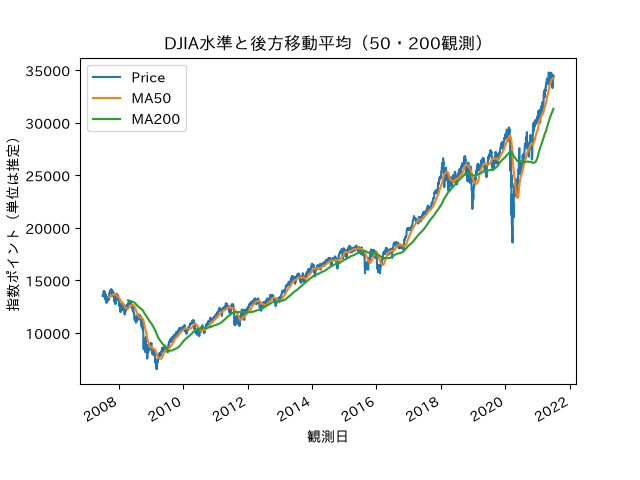

In [11]:
show_chart('chart-level', df[['Date','Price','MA50','MA200']], 'line', 'Date', None, 'DJIA水準と後方移動平均（50・200観測）', '観測日', '指数ポイント（単位は推定）', ['Price', 'MA50', 'MA200'])

図表ログ: {"id": "chart-loglevel", "missing_glyphs": [], "title": "基準日からの対数価格比：相対的な成長", "xlabel": "観測日", "ylabel": "log（価格 / 初日の価格）", "legend": ["log_ratio"], "png_bytes": 44033}


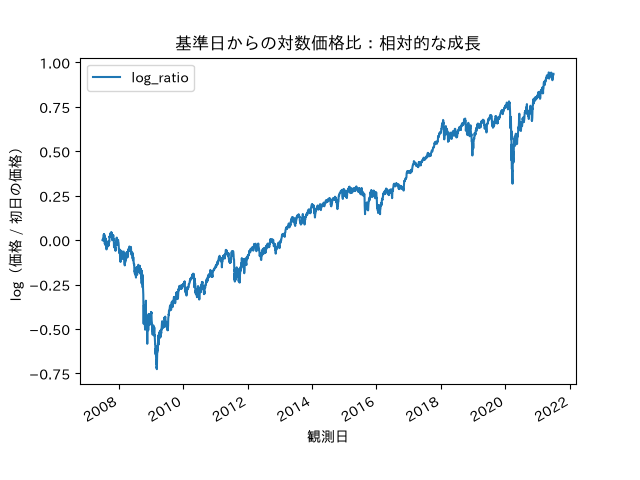

In [12]:
show_chart('chart-loglevel', pd.DataFrame({'Date': df['Date'], 'log_ratio': np.log(df['Price']/df['Price'].iloc[0])}), 'line', 'Date', 'log_ratio', '基準日からの対数価格比：相対的な成長', '観測日', 'log（価格 / 初日の価格）', ['log_ratio'])

図表ログ: {"id": "chart-returns", "missing_glyphs": [], "title": "隣接する観測取引日間の単純リターン", "xlabel": "観測日", "ylabel": "リターン（%）", "legend": ["Return_pct"], "png_bytes": 37898}


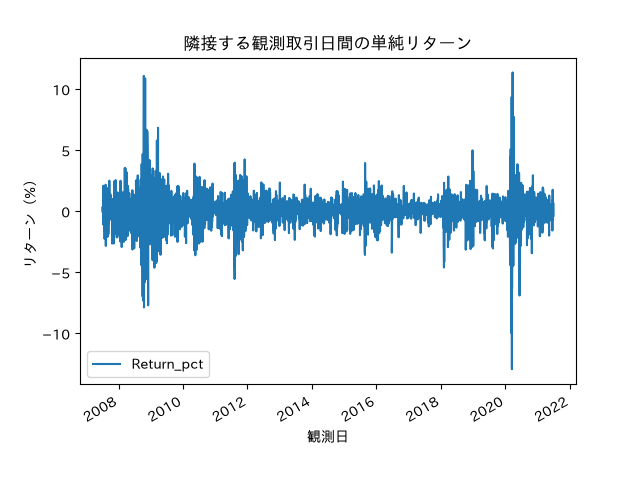

In [13]:
show_chart('chart-returns', pd.DataFrame({'Date': df['Date'], 'Return_pct': df['Return']*100}), 'line', 'Date', 'Return_pct', '隣接する観測取引日間の単純リターン', '観測日', 'リターン（%）', ['Return_pct'])

図表ログ: {"id": "chart-volatility", "missing_glyphs": [], "title": "ローリング年率変動性：窓長への依存", "xlabel": "観測日", "ylabel": "対数リターン標準偏差 × √252（%）", "legend": ["Vol21", "Vol63", "Vol126"], "png_bytes": 66532}


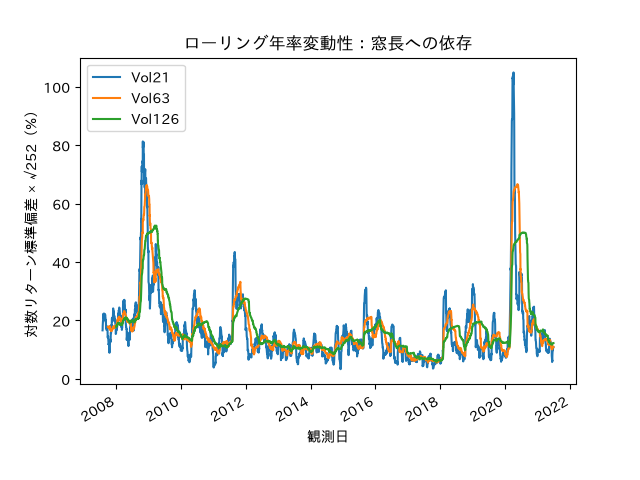

In [14]:
show_chart('chart-volatility', df[['Date','Vol21','Vol63','Vol126']], 'line', 'Date', None, 'ローリング年率変動性：窓長への依存', '観測日', '対数リターン標準偏差 × √252（%）', ['Vol21', 'Vol63', 'Vol126'])

図表ログ: {"id": "chart-drawdown", "missing_glyphs": [], "title": "観測期間内の直前最高値からのドローダウン", "xlabel": "観測日", "ylabel": "ドローダウン（%）", "legend": ["drawdown_pct"], "png_bytes": 46106}


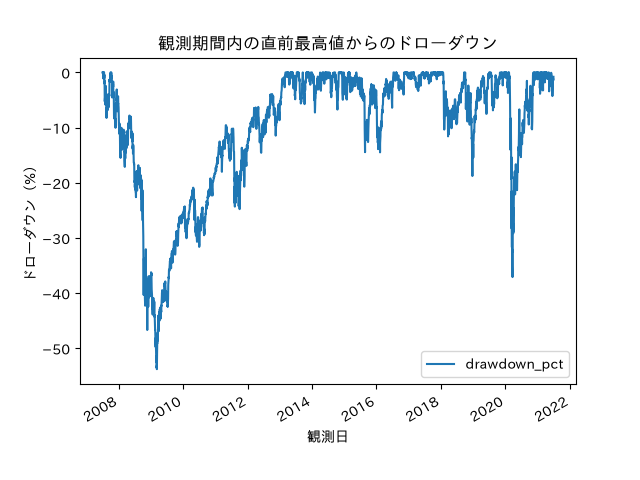

In [15]:
show_chart('chart-drawdown', pd.DataFrame({'Date': df['Date'], 'drawdown_pct': df['Drawdown']*100}), 'line', 'Date', 'drawdown_pct', '観測期間内の直前最高値からのドローダウン', '観測日', 'ドローダウン（%）', ['drawdown_pct'])

図表ログ: {"id": "chart-distribution", "missing_glyphs": [], "title": "日次リターン分布：中心と大きな変動", "xlabel": "リターン（%）", "ylabel": "観測回数（自動ビン10個）", "legend": ["単一系列、凡例不要"], "png_bytes": 20317}


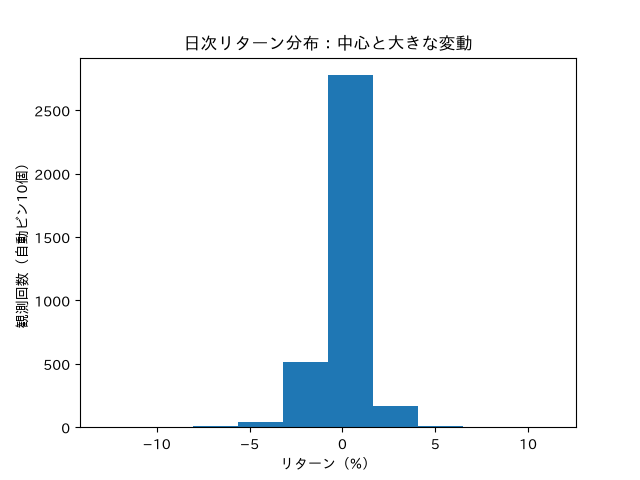

In [16]:
show_chart('chart-distribution', pd.DataFrame({'Return_pct': df['Return'].dropna()*100}), 'hist', 'Return_pct', None, '日次リターン分布：中心と大きな変動', 'リターン（%）', '観測回数（自動ビン10個）', ['単一系列、凡例不要'])

観測系列は2007-07-02から2021-06-30の3,524水準。13,535.43から34,502.51へ約154.91%上昇し、暦時間のCAGRは約6.91%。これはPrice欄の相対変化であって、配当再投資・手数料・物価を考慮した投資収益ではない。

```evidence
{"execution_count": 7, "cited_value": "154.90516370739607", "claim_type": "descriptive"}
```

観測期間内の最大ドローダウンは約-53.78%。2007-10-09の高値から2009-03-09の底へ下落し、同じ水準への回復は2013-03-05だった。観測開始前の高値や日中価格は含まない。2020年の最大日次下落は約-12.93%、最大上昇は約11.37%。長期の上昇と短期の損失は両立する。

```evidence
{"execution_count": 7, "cited_value": "-53.778558130767486", "claim_type": "descriptive"}
```

水準の1期自己相関は約0.99946、リターンは約-0.14820、絶対リターンは約0.36153。水準の滑らかさと相対変化の予測を区別する必要がある。超過尖度約14.95は、単純な正規分布より大きな変動が多いことを示唆する。Pearsonの標準p値は時間依存を無視するので確証として使わない。

```evidence
{"execution_count": 7, "cited_value": "0.3615337608853655", "claim_type": "descriptive"}
```

相関係数は 0.3615 (p=3.18e-109) で、中程度の正の相関が見られます。 これは隣接する絶対リターンの記述的関係であり、標準p値の独立性仮定は満たすと確認できない。因果解釈・将来方向予測には用いない。

```evidence
{"execution_count": 7, "cited_value": "3.180186931418572e-109", "claim_type": "associational"}
```

年率変動性は単純/対数リターンと250/252日の4仕様で19.91–20.03%。stable=True、最大相対偏差は約0.005923（0.59%）と5%閾値以内。一方、6つの開始・終了期間でCAGRは6.15–10.84%。全て正だがstable=False、最大相対偏差約0.7620（76.2%）で20%閾値を超える。上昇の方向と成長率の大きさの頑健性は別である。

```evidence
{"execution_count": 8, "cited_value": "0.005922600058654571", "claim_type": "descriptive"}
```

時系列順80/20の検証では、1観測先の対数変化RMSEは無変化モデル約1.57481%、学習ドリフト約1.57439%で差は極小。21観測先も約6.70%と6.66%。正規・固定分散の名目95%区間の被覆率は仕様により約92.5–94.0%で、95%の保証ではない。1分割と重複21日先だけでモデル優位を断定しない。

```evidence
{"execution_count": 9, "cited_value": "1.574808251498864", "claim_type": "descriptive"}
```

## 反復依頼履歴

### 反復1：選定理由
全期間の負のリターン相関と正の絶対リターン相関を確認した。標準Pearson p値では時系列依存を処理できず、危機局面に依存した現象かも未解決である。

**追加依頼文（原文）**

初回分析で日次リターンの1期自己相関が約-0.148、絶対リターンの自己相関が約0.362でした。負の相関を予測可能性と早合点しないため、2007–2009年・2010–2019年・2020–2021年で両者を比較し、時間依存を残すブロック・ブートストラップをブロック長5・21・63観測で実施してください。極端な変動を削除せず、各信頼区間の仮定と局面の違いを説明してください。

In [17]:
with phase('iteration_1_regimes_and_block_bootstrap'):
    regimes = [('2007-2009','2007-07-02','2009-12-31'), ('2010-2019','2010-01-01','2019-12-31'), ('2020-2021','2020-01-01','2021-06-30')]
    regime_rows = []
    for name,start,end in regimes:
        values = df.loc[df['Date'].between(start,end), 'Return'].dropna()
        regime_rows.append({'period': name, 'n': len(values), 'return_ACF1': float(values.autocorr(1)), 'abs_return_ACF1': float(values.abs().autocorr(1)), 'annual_vol_pct': float(np.log1p(values).std(ddof=1)*np.sqrt(252)*100)})
    values = df['Return'].dropna().to_numpy()
    B = 600
    bootstrap_rows = []
    for block_length in [5,21,63]:
        rng = np.random.default_rng(16100+block_length)
        nblocks = int(np.ceil(len(values)/block_length))
        samples = np.empty((B,2))
        for b in range(B):
            starts = rng.integers(0,len(values),size=nblocks)
            indices = (starts[:,None]+np.arange(block_length)) % len(values)
            sample = values[indices.ravel()[:len(values)]]
            samples[b,0] = np.corrcoef(sample[:-1],sample[1:])[0,1]
            samples[b,1] = np.corrcoef(np.abs(sample[:-1]),np.abs(sample[1:]))[0,1]
        for j,label in enumerate(['return_ACF1','abs_return_ACF1']):
            low, high = np.quantile(samples[:,j],[0.025,0.975])
            bootstrap_rows.append({'metric': label, 'block_length': block_length, 'resamples': B, 'seed': 16100+block_length, 'percentile_95_low': float(low), 'percentile_95_high': float(high)})
    iteration1_summary = {'regimes': regime_rows, 'block_bootstrap': bootstrap_rows, 'abs_ACF_positive_all_block_CIs': all(row['percentile_95_low']>0 for row in bootstrap_rows if row['metric']=='abs_return_ACF1'), 'return_ACF_negative_all_block_CIs': all(row['percentile_95_high']<0 for row in bootstrap_rows if row['metric']=='return_ACF1'), 'limits': '円環移動ブロック法・600反復・百分位区間。ブロック境界で依存が切れ、定常性近似を置く。市場局面変化を再現する将来信頼区間ではない。選んだ期間は探索的で、後続予測のチューニングには使わない。'}
    display(iteration1_summary)


{'regimes': [{'period': '2007-2009',
   'n': 631,
   'return_ACF1': -0.14519813805940396,
   'abs_return_ACF1': 0.21139010248454154,
   'annual_vol_pct': 29.50360599900489},
  {'period': '2010-2019',
   'n': 2515,
   'return_ACF1': -0.042879516666886414,
   'abs_return_ACF1': 0.21729864755245865,
   'annual_vol_pct': 14.086837222251155},
  {'period': '2020-2021',
   'n': 377,
   'return_ACF1': -0.30006359007799877,
   'abs_return_ACF1': 0.5279655350074766,
   'annual_vol_pct': 31.134188151892634}],
 'block_bootstrap': [{'metric': 'return_ACF1',
   'block_length': 5,
   'resamples': 600,
   'seed': 16105,
   'percentile_95_low': -0.2092629368509464,
   'percentile_95_high': -0.047289471696643506},
  {'metric': 'abs_return_ACF1',
   'block_length': 5,
   'resamples': 600,
   'seed': 16105,
   'percentile_95_low': 0.20153693165688227,
   'percentile_95_high': 0.39383344171754686},
  {'metric': 'return_ACF1',
   'block_length': 21,
   'resamples': 600,
   'seed': 16121,
   'percentile_95_l

反復1の結果：絶対リターンの1期自己相関は全ての局面で正（約0.211・0.217・0.528）。ブロック長5・21・63の全区間でも下端は正だった。日次リターンの相関は約-0.145・-0.043・-0.300で、全期ブロック区間は全て負だが局面で大きさが違う。変動の集中は記述的に支持される一方、一定の反転予測則はまだ証明されない。根拠セル `iteration-1` の局面表・ブートストラップ表。残る限界は定常性近似、600反復、局面の探索的選択、構造変化を将来再現できないこと。

```evidence
{"execution_count": 17, "cited_value": "True", "claim_type": "descriptive"}
```

### 反復2：選定理由
相関の存在だけではアウトオブサンプル予測が有効とはいえない。危機期と平常期の相関差が予測誤差にも現れるかが、結論に実質的な影響を与える。

**追加依頼文（原文）**

反復1では負のリターン自己相関が局面で大きく変わり、2010–2019年は約-0.043、2020–2021年は約-0.300でした。この関係が実際に予測誤差を減らすか確認するため、先頭60・70・80%で学習した固定AR(1)を、無変化・固定ドリフトと1観測先の時系列順検証で比較してください。係数は検証期間中に再学習せず、2018–2019年・2020年・2021年の評価も表示し、方向的中率だけで収益性を主張しないでください。

In [18]:
with phase('iteration_2_AR1_chronological_validation'):
    log_prices = np.log(df['Price'].to_numpy())
    log_returns_array = np.diff(log_prices)
    model_rows = []
    split_detail = {}
    for fraction in [0.6,0.7,0.8]:
        cut = int(len(df)*fraction)
        train_returns = log_returns_array[:cut-1]
        X = np.column_stack([np.ones(len(train_returns)-1),train_returns[:-1]])
        intercept, phi = np.linalg.lstsq(X, train_returns[1:], rcond=None)[0]
        origins = np.arange(cut-1,len(df)-1)
        target = log_prices[origins+1]-log_prices[origins]
        lag = log_prices[origins]-log_prices[origins-1]
        predictions = {'random_walk': np.zeros(len(origins)), 'drift': np.full(len(origins),train_returns.mean()), 'AR1': intercept+phi*lag}
        dates = df['Date'].iloc[origins+1].reset_index(drop=True)
        masks = {'all_test': np.ones(len(origins),dtype=bool), '2018-2019': dates.between('2018-01-01','2019-12-31').to_numpy(), '2020': dates.dt.year.eq(2020).to_numpy(), '2021_partial': dates.dt.year.eq(2021).to_numpy()}
        for period,mask in masks.items():
            if not mask.any():
                continue
            for model,pred in predictions.items():
                err = target[mask]-pred[mask]
                rw_rmse = np.sqrt(np.mean(target[mask]**2))
                rmse = np.sqrt(np.mean(err**2))
                model_rows.append({'train_fraction': fraction, 'train_end': str(df['Date'].iloc[cut-1].date()), 'period': period, 'model': model, 'n': int(mask.sum()), 'train_phi': float(phi) if model=='AR1' else None, 'RMSE_log_pct': float(rmse*100), 'MAE_log_pct': float(np.mean(np.abs(err))*100), 'RMSE_reduction_vs_RW_pct': float((1-rmse/rw_rmse)*100), 'direction_accuracy': float(np.mean(np.sign(pred[mask])==np.sign(target[mask]))) if model!='random_walk' else None})
        split_detail[fraction] = {'target': target, 'dates': dates, 'predictions': predictions}
    ar1_values = {fraction: next(row['RMSE_reduction_vs_RW_pct'] for row in model_rows if row['train_fraction']==fraction and row['period']=='all_test' and row['model']=='AR1') for fraction in [0.6,0.7,0.8]}
    ar_plan = sensitivity.SensitivityPlan(parameter_grid={'train_fraction': [0.6,0.7,0.8]}, max_runs=3)
    ar_report = sensitivity.run_sensitivity(ar_plan, lambda train_fraction: ar1_values[train_fraction], stability_tolerance=0.20)
    iteration2_summary = {'AR1_reduction_vs_RW_all_test_pct': ar1_values, 'split_sensitivity': asdict(ar_report), 'all_test_AR1_lower_RMSE_than_RW': all(v>0 for v in ar1_values.values()), 'protocol': '切点ごとに過去だけでAR1係数・driftを固定。予測起点の観測済みlagだけを使用。分割は探索的感度検査であり、最良分割の選別や取引戦略の成績とはしない。'}
    display(iteration2_summary)
    display(pd.DataFrame(model_rows))


{'AR1_reduction_vs_RW_all_test_pct': {0.6: 1.7179001100313451,
  0.7: 1.8493045077539239,
  0.8: 2.026869572651624},
 'split_sensitivity': {'results': ({'specification': {'train_fraction': 0.6},
    'value': 1.7179001100313451},
   {'specification': {'train_fraction': 0.7}, 'value': 1.8493045077539239},
   {'specification': {'train_fraction': 0.8}, 'value': 2.026869572651624}),
  'baseline_value': 1.7179001100313451,
  'stable': True,
  'max_relative_deviation': 0.17985298494138946},
 'all_test_AR1_lower_RMSE_than_RW': True,
 'protocol': '切点ごとに過去だけでAR1係数・driftを固定。予測起点の観測済みlagだけを使用。分割は探索的感度検査であり、最良分割の選別や取引戦略の成績とはしない。'}

,train_fraction,train_end,period,model,n,train_phi,RMSE_log_pct,MAE_log_pct,RMSE_reduction_vs_RW_pct,direction_accuracy
0,0.6,2015-11-20,all_test,random_walk,1410,NaN,1.236564,0.721203,0.000000,NaN
1,0.6,2015-11-20,all_test,drift,1410,NaN,1.236139,0.719864,0.034361,0.554610
2,0.6,2015-11-20,all_test,AR1,1410,-0.106515,1.215321,0.714906,1.717900,0.525532
3,0.6,2015-11-20,2018-2019,random_walk,503,NaN,0.972821,0.679398,0.000000,NaN
4,0.6,2015-11-20,2018-2019,drift,503,NaN,0.972526,0.678041,0.030353,0.554672
5,0.6,2015-11-20,2018-2019,AR1,503,-0.106515,0.975909,0.682309,-0.317368,0.493042
6,0.6,2015-11-20,2020,random_walk,253,NaN,2.328808,1.421486,0.000000,NaN
7,0.6,2015-11-20,2020,drift,253,NaN,2.328690,1.420135,0.005077,0.553360
8,0.6,2015-11-20,2020,AR1,253,-0.106515,2.264538,1.385059,2.759793,0.561265
9,0.6,2015-11-20,2021_partial,random_walk,124,NaN,0.778552,0.584572,0.000000,NaN


反復2の結果：60/70/80%学習のAR(1)は全検証期間のRMSEを無変化に比べ約1.72/1.85/2.03%改善した。分割感度はstable=True、最大相対偏差約0.17985（18.0%）と20%閾値以内。ただし2018–2019年は3分割全てで約0.30–0.37%悪化、2020年は約2.65–2.76%改善、2021年は約0.23–0.42%改善。一定の性能ではなく、危機期に依存する。根拠セル `iteration-2` の全体・局面表。残る限界は分割の重複、探索的AR1選択、誤差改善の不確実性、費用と実際の売買を未評価であること。

```evidence
{"execution_count": 18, "cited_value": "0.17985298494138946", "claim_type": "descriptive"}
```

### 反復3：選定理由
RMSE改善の符号だけで有効なモデルと断定すると危機期への依存を見落とす。初回の95%区間も平均被覆率だけでは危機期の欠陥が見えない。不確実性と局面別リスク校正を追加する。

**追加依頼文（原文）**

反復2でAR(1)の全検証期間RMSEは無変化より約1.7–2.0%低くなりましたが、2018–2019年には悪化し、改善は主に2020年に集中していました。80%学習の対応した誤差を使い、ブロック長5・21・63の再標本化でRMSE改善率の不確実性を確認してください。また、固定分散の名目95%区間を2020年などの局面別に検証し、過去データだけで更新するEWMA（λ=0.94・0.97・0.99）と比較してください。被覆率だけでなく区間幅と95%区間スコアも表示し、予測保証や取引収益とは区別してください。

In [19]:
with phase('iteration_3_forecast_uncertainty_and_calibration'):
    detail = split_detail[0.8]
    target = detail['target']
    ar_errors = target-detail['predictions']['AR1']
    rmse_ci = []
    B = 1000
    for block_length in [5,21,63]:
        rng = np.random.default_rng(16300+block_length)
        nblocks = int(np.ceil(len(target)/block_length))
        draws = np.empty(B)
        for b in range(B):
            starts = rng.integers(0,len(target),size=nblocks)
            indices = ((starts[:,None]+np.arange(block_length)) % len(target)).ravel()[:len(target)]
            draws[b] = (1-np.sqrt(np.mean(ar_errors[indices]**2))/np.sqrt(np.mean(target[indices]**2)))*100
        low,high = np.quantile(draws,[0.025,0.975])
        rmse_ci.append({'block_length': block_length, 'B': B, 'seed': 16300+block_length, 'improvement_pct_low': float(low), 'improvement_pct_high': float(high)})
    cut = int(len(df)*0.8)
    train_returns = np.diff(np.log(df['Price'].to_numpy()[:cut]))
    variance0 = float(np.var(train_returns,ddof=1))
    widths = {'fixed_train_sigma': np.full(len(target),1.96*np.sqrt(variance0))}
    for lam in [0.94,0.97,0.99]:
        variance = variance0
        halfwidth = np.empty(len(target))
        for t in range(len(target)):
            if t>0:
                variance = lam*variance+(1-lam)*target[t-1]**2
            halfwidth[t] = 1.96*np.sqrt(variance)
        widths['EWMA_'+str(lam)] = halfwidth
    dates = detail['dates']
    masks = {'all_test': np.ones(len(target),dtype=bool), '2018-2019': dates.between('2018-01-01','2019-12-31').to_numpy(), '2020': dates.dt.year.eq(2020).to_numpy(), '2021_partial': dates.dt.year.eq(2021).to_numpy()}
    interval_rows = []
    for period,mask in masks.items():
        for model,halfwidth in widths.items():
            outside = np.maximum(np.abs(target[mask])-halfwidth[mask],0)
            interval_score = 2*halfwidth[mask]+40*outside
            interval_rows.append({'period': period, 'model': model, 'n': int(mask.sum()), 'nominal_coverage': 0.95, 'observed_coverage': float(np.mean(np.abs(target[mask])<=halfwidth[mask])), 'mean_fullwidth_log_pct': float(np.mean(2*halfwidth[mask])*100), 'mean_95_interval_score_pct': float(np.mean(interval_score)*100)})
    fixed_2020 = next(row['observed_coverage'] for row in interval_rows if row['period']=='2020' and row['model']=='fixed_train_sigma')
    iteration3_summary = {'paired_AR1_RMSE_improvement_95pct_CI': rmse_ci, 'all_improvement_CI_lower_positive': all(row['improvement_pct_low']>0 for row in rmse_ci), 'fixed_sigma_2020_coverage': fixed_2020, 'interval_protocol': '無変化を中心とする対数変化区間。EWMAは前の検証リターンが観測された後だけ更新。lambdaは事前グリッドで比較し最良値を選ばない。スコア=区間全幅+40×区間外距離（小さいほど良い）。', 'limits': 'RMSE区間は固定済みモデルの条件付き再標本化。学習係数の不確実性・非定常な将来・探索的モデル選択を含まない。EWMAは正規分布を依然仮定し、最初の大変動を先取りできない。'}
    display(iteration3_summary); display(pd.DataFrame(interval_rows))


{'paired_AR1_RMSE_improvement_95pct_CI': [{'block_length': 5,
   'B': 1000,
   'seed': 16305,
   'improvement_pct_low': -0.17563577103481606,
   'improvement_pct_high': 3.7400350345227156},
  {'block_length': 21,
   'B': 1000,
   'seed': 16321,
   'improvement_pct_low': -0.312246563681956,
   'improvement_pct_high': 3.2796520949563126},
  {'block_length': 63,
   'B': 1000,
   'seed': 16363,
   'improvement_pct_low': -0.4330100293385364,
   'improvement_pct_high': 3.0420132852713992}],
 'all_improvement_CI_lower_positive': False,
 'fixed_sigma_2020_coverage': 0.8458498023715415,
 'interval_protocol': '無変化を中心とする対数変化区間。EWMAは前の検証リターンが観測された後だけ更新。lambdaは事前グリッドで比較し最良値を選ばない。スコア=区間全幅+40×区間外距離（小さいほど良い）。',
 'limits': 'RMSE区間は固定済みモデルの条件付き再標本化。学習係数の不確実性・非定常な将来・探索的モデル選択を含まない。EWMAは正規分布を依然仮定し、最初の大変動を先取りできない。'}

,period,model,n,nominal_coverage,observed_coverage,mean_fullwidth_log_pct,mean_95_interval_score_pct
0,all_test,fixed_train_sigma,705,0.95,0.926241,4.587640,10.501877
1,all_test,EWMA_0.94,705,0.95,0.934752,4.902294,7.361896
2,all_test,EWMA_0.97,705,0.95,0.936170,5.207173,8.129623
3,all_test,EWMA_0.99,705,0.95,0.947518,5.721130,9.549138
4,2018-2019,fixed_train_sigma,328,0.95,0.960366,4.587640,5.629628
5,2018-2019,EWMA_0.94,328,0.95,0.945122,3.655819,5.052257
6,2018-2019,EWMA_0.97,328,0.95,0.948171,3.838638,5.139446
7,2018-2019,EWMA_0.99,328,0.95,0.954268,4.161043,5.336072
8,2020,fixed_train_sigma,253,0.95,0.845850,4.587640,19.717145
9,2020,EWMA_0.94,253,0.95,0.920949,7.430922,11.919337


## Jupytermind改善候補
### 候補1：stream出力の証拠解決
分類：機能不足（証拠出力型の対応範囲）。再現条件：`clean-quality` のprint出力「検査済み行数=3524」を、そのセルの実行番号で `record_insight` に引用する。期待：標準Jupyter stream.textでも実行証拠として認める。実際：`EvidenceMissingError`。影響：printだけの結果を根拠付き洞察にできない。回避策：同じ結果をdisplayしたtext/plain出力で記録する。本分析の洞察は全てこの方法で記録している。関係セルとログ：次の `improvement-reproduction` の構造化出力、および `clean-quality`。Copilot CLI・Kaggle API・ベンチマークランナーには依存しないモジュールの再現である。

In [20]:
import nbformat
from ai_data_scientist import insight_engine
with phase('reproduce_stream_evidence_gap'):
    notebook = nbformat.read(handle.notebook_path, as_version=4)
    quality_cell = next(c for c in notebook.cells if c.id=='clean-quality')
    stream_text = ''.join(o.get('text','') for o in quality_cell.outputs if o.output_type=='stream')
    stream_citation = insight_engine.extract_cited_value({'output': stream_text}, r'(検査済み行数=\d+)')
    before_sha = hashlib.sha256(handle.notebook_path.read_bytes()).hexdigest()
    try:
        insight_engine.record_insight(handle, 'stream証拠の再現確認', quality_cell.execution_count, stream_citation, 'descriptive', language='ja')
    except insight_engine.EvidenceMissingError:
        reproduction = {'classification': 'Jupytermind機能不足候補', 'module': 'ai_data_scientist.insight_engine.record_insight', 'condition': '実行済みセルのstream.textだけに存在する引用', 'expected': '標準Jupyter stream出力も実行証拠として解決', 'actual': 'EvidenceMissingError。data MIME bundleだけが検索される', 'impact': 'printだけの結果で根拠付き洞察を書けない', 'workaround': 'display(dict)またはdisplay(JSON)のtext/plainで同じ結果を記録', 'related_cell_id': 'clean-quality', 'evidence_execution_count': quality_cell.execution_count, 'stream_citation': stream_citation, 'notebook_unchanged': before_sha == hashlib.sha256(handle.notebook_path.read_bytes()).hexdigest()}
        display(reproduction)
    else:
        raise RuntimeError('想定したstream制約が再現しなかった。改善候補を更新する必要あり。')


{'classification': 'Jupytermind機能不足候補',
 'module': 'ai_data_scientist.insight_engine.record_insight',
 'condition': '実行済みセルのstream.textだけに存在する引用',
 'expected': '標準Jupyter stream出力も実行証拠として解決',
 'actual': 'EvidenceMissingError。data MIME bundleだけが検索される',
 'impact': 'printだけの結果で根拠付き洞察を書けない',
 'workaround': 'display(dict)またはdisplay(JSON)のtext/plainで同じ結果を記録',
 'related_cell_id': 'clean-quality',
 'evidence_execution_count': 5,
 'stream_citation': '検査済み行数=3524',
 'notebook_unchanged': True}

反復3の結果：80%学習AR(1)のRMSE改善率の95%百分位区間は、ブロック5で約[-0.176, 3.740]%、21で[-0.312, 3.280]%、63で[-0.433, 3.042]%。全てゼロを含み、小さな予測優位は確証されない。固定分散の名目95%区間の2020年被覆率は約84.58%、EWMAでは約91.30–92.09%で改善したが95%に届かない。EWMAの区間幅は危機時に広がるため、区間スコアも併記した。根拠セル `iteration-3` の対応ブートストラップ表と校正表。残る限界は固定モデル条件付きの区間、未評価の学習係数不確実性、構造変化、探索的選択、正規近似である。

```evidence
{"execution_count": 19, "cited_value": "0.8458498023715415", "claim_type": "descriptive"}
```

最終結論：過去の水準は長期上昇したが、その途中には50%を超す下落と長い回復期間がある。リターンは水準の差ではなく相対変化で、ゼロ近辺の小変動と危機時の大変動が混在する。金額差は水準が上がるほど大きくなりやすいため、異なる時期の比較にはリターンと対数価格比を使う。移動平均は過去の平滑化であり売買シグナルの有効性検証ではない。年率換算とCAGRは将来収益率の予測ではなく、配当・税・費用・物価調整・個別銘柄の収益も保証しない。

```evidence
{"execution_count": 7, "cited_value": "6.91409554814304", "claim_type": "descriptive"}
```

### 候補2：実行中セルと同一Notebookの書込みの連携制約（原因未確定）
分類：JupytermindとJupyter MCPの統合上の改善候補。再現条件：`final-audit` 実行中に同じNotebookへ `project_manager.enqueue_write` で証拠metadataを更新する。期待：実行中セルの番号と出力も保存される。実際：2026-10-01T17:37:18 UTCの実行・書込みphaseとcompleted状態は残ったが、MCPのセル実行応答は空で、保存された `final-audit` はexecution_count=None、outputs=[]だった。影響：自己監査の末尾除外だけでは未保存セルを見落とせる。回避策：Notebook構造・証拠の更新を別の準備Notebookから行い、監査セル内では同一Notebookを変更しない。修正版を全セル再実行し、保存後の21/21実行監査を追加する。関係セル：旧 `final-audit`、準備セルの修正ログ、現在の読取り専用 `final-audit`。MCPと文書モデルの同期が関与し、Jupytermind単体の不具合と断定しない。Kaggle API、Copilot CLI、ベンチマークランナーの問題とは区別する。

**実測ログの抜粋（最初の再実行で観測した状態）**
```json
{
  "mcp_execute_cell_outputs": [],
  "saved_final_audit_execution_count": null,
  "saved_final_audit_outputs_count": 0,
  "lifecycle_state": "completed",
  "active_cell_executions": 0,
  "pending_notebook_writes": 0,
  "locks_held": 0,
  "subsequent_workaround_validation": "同一Notebook書込みを監査セルから除外後、再起動して21/21実行と出力保存を確認"
}
```

## 使用したJupytermindモジュール
直接import・呼び出したものだけを記録する。名前空間は `ai_data_scientist`。間接依存は使用済みに含めない。

| モジュール | 直接呼び出した関数・型 | 使用目的 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | slug検証、保存先・dataの固定、Notebook内容の直列書込み |
| language_router | detect_language | 日本語を確認 |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | 実行/書込みの記録、中止確認、終了状態 |
| ingestion | SourceSpec, ingest | SDKで取得したローカルCSVの制限付き読込み |
| cleaning | clean_dataset | 重複処理と影響報告（削除0行、7列が対象） |
| eda | explore | 水準・リターン・出来高の型、欠損、要約 |
| data_quality | detect_anomalies | 日付・曜日・OHLC・範囲などの意味的検査 |
| anomaly_detection | detect_anomalies | 3σ超61件を旗付け。削除しない |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 来歴と定義のverified/inferred/unknown区別 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 記述的範囲と未解決の重要前提A1/A5を可視化 |
| stats_analysis | correlation | 隣接絶対リターンの相関と日本語解釈。標準p値は確証に使わない |
| sensitivity | SensitivityPlan, run_sensitivity | 年率係数・リターン定義・期間・学習切点の感度 |
| visualization | render_chart, build_image_output | 日本語ラベル付きPNG6図をMIME出力として記録 |
| insight_engine | extract_cited_value, record_insight | 実行済みtext/plainから厳密な引用を抽出し根拠付き洞察を記録。stream制約も再現 |
| notebook_audit | audit_notebook（visual_audit=True） | 実行・証拠・PNG・図表metadataの最終監査 |

Notebook構造とmetadataの変更はJupyter MCPで動く準備セルからenqueue_writeを呼んだ。各分析セルそのものと出力の実行保存には実Jupyter MCPのexecute_cellを使った。カーネル内へホストのMCPClientを渡せないのでmcp_gateway.run_and_recordは呼んでおらず、利用済みとは記録しない。実行を偽装するクライアント・ローカルexec・subprocess・端末・外部スクリプト・作業エージェントは使用していない。

### 適用範囲と未解決の注意
データ辞書、原提供者、配当/物価調整、日時のタイムゾーン、独立した取引日完全性は未確認。頻度・終値・ポイント単位は推定。A1（Priceの終値解釈）とA5（独立参照の保証）はcheck_manifestの警告として残す。独立参照のcompare_datasets/validate_anomaliesは未適用。高い絶対リターン相関や危機年の高変動性はイベントの因果効果を証明しない。季節性・因果推論・出来高の経済的解釈・AutoMLは本課題と定義に合わず未適用。

### 反復停止理由
3回の追加分析で、自己相関の局面差、予測誤差への寄与、その不確実性、危機期の区間校正を確認した。さらに分割やモデルを探索すると同じ検証期間への過適合を増やす。残る主な問題は独立参照・データ辞書と2021年以降の真に未見の期間がないことで、このデータ内の追加モデルだけでは解決しない。上限3回で停止し、未解決点を予測限界として残す。


## 再実行と最終監査
カーネルを再起動して全コードセルを上からJupyter MCPで再実行する。既存CSVは来歴とSHA-256一致を確認して再利用し、Kaggleの認証・候補検索・ファイル一覧は再呼出しする。初回数値・3反復結果・全6図のPNGバイトハッシュを保存済み基準と完全一致検査する。初回の根拠manifestを再実行番号へ準備用MCPセルで再解決済み。今後はカーネル再起動＋上から全セル実行で実行番号を固定し、最後に保存された引用と番号の一致を検査してvisual_audit=Trueで監査し、run_idをcompletedへ進める。最後の監査セルの実行終了前は監査仕様でその1セルを除外するため、保存後にも読取り専用の完全監査を行ってmetadataに記録する。

### 保存後の完全監査結果
カーネル再起動後に21コードセルを順番通り再実行し、実行番号1–21を確認した。初回の数値・反復結果・6図のPNGバイトが完全一致した。保存後のaudit_notebook(visual_audit=True)はok=True、21/21実行済み、エラー0、未実行0、図6、根拠付き洞察10、図表指摘0。run_id `v020-exp-16` はcompleted、実行0・書込み0・ロック0。構造化結果はNotebook metadataとdata/notebook-audit-post-save.jsonに記録。

再実行は同じリポジトリ・dataディレクトリ・依存バージョン・Kaggle認証がある環境で、カーネルを再起動してから全セルを上から実行する。最新データへの自動更新ではなく、ハッシュ固定の取得スナップショットを再現する。

In [21]:
import base64
import importlib.metadata
from ai_data_scientist import notebook_audit
with phase('replay_equality_and_evidence_refresh'):
    stored = nbformat.read(handle.notebook_path, as_version=4)
    actual_chart_hashes = {c.id: hashlib.sha256(base64.b64decode(next(o['data']['image/png'] for o in c.outputs if 'image/png' in o.get('data', {})))).hexdigest() for c in stored.cells if c.cell_type=='code' and c.id.startswith('chart-') and any('image/png' in o.get('data', {}) for o in c.outputs)}
    actual_replay = {'summary': summary, 'quality': quality_summary, 'sensitivity': sensitivity_summary, 'forecast': forecast_summary, 'iteration1': iteration1_summary, 'iteration2': iteration2_summary, 'iteration3': iteration3_summary, 'charts_sha256': actual_chart_hashes}
    replay_json = json.dumps(actual_replay, ensure_ascii=False, sort_keys=True, separators=(',', ':'), allow_nan=False)
    baseline_json = (data_dir / 'replay-baseline.json').read_text()
    replay_matches = replay_json == baseline_json
    if not replay_matches:
        expected = json.loads(baseline_json)
        differing_groups = [key for key in actual_replay if json.dumps(actual_replay[key],sort_keys=True) != json.dumps(expected[key],sort_keys=True)]
        raise RuntimeError('初回結果と再実行結果が不一致: ' + ', '.join(differing_groups))
with phase('verify_saved_evidence_bindings'):
    for cell in stored.cells:
        evidence_id = cell.metadata.get('evidence_cell_id')
        if evidence_id:
            evidence = next(c for c in stored.cells if c.id==evidence_id)
            manifest = json.loads(re.search(r'```evidence\n(.*?)\n```',cell.source,re.DOTALL).group(1))
            text = '\n'.join(str(o.get('data',{}).get('text/plain','')) for o in evidence.outputs)
            cited = insight_engine.extract_cited_value({'output': text}, cell.metadata['evidence_pattern'])
            if cited != manifest['cited_value'] or evidence.execution_count != manifest['execution_count']:
                raise RuntimeError('引用または実行番号不一致。カーネルを再起動し全セルを上から実行する必要あり。')
with phase('notebook_and_visual_audit'):
    audit = notebook_audit.audit_notebook(handle.notebook_path, visual_audit=True)
    display({'audit_ok': audit.ok, 'report': asdict(audit), 'reexecution_exact_match': replay_matches, 'dataset_sha256': actual_hash})
    if not audit.ok:
        raise RuntimeError('Notebook監査に未解決エラーあり')
    display({'versions': {name: importlib.metadata.version(name) for name in ['pandas','numpy','scipy','matplotlib','kaggle','japanize-matplotlib']}, 'python': sys.version.split()[0]})
with phase('persist_audit_and_lifecycle_log', writing=True):
    (data_dir / 'notebook-audit.json').write_text(json.dumps({'ok': audit.ok, **asdict(audit)}, ensure_ascii=False, indent=2))
    (data_dir / 'lifecycle-phases.json').write_text(json.dumps(phase_log, ensure_ascii=False, indent=2))
lifecycle.mark_completed(RUN_ID)
status = lifecycle.wait_for_quiescence(RUN_ID, timeout_s=5)
(data_dir / 'lifecycle-status.json').write_text(json.dumps(asdict(status), ensure_ascii=False, indent=2))
print('終了状態:', json.dumps(asdict(status), ensure_ascii=False))
assert status.state == 'completed' and status.active_cell_executions == 0 and status.pending_notebook_writes == 0 and status.locks_held == 0


終了状態: {"run_id": "v020-exp-16", "state": "completed", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-16-dowjones/notebooks/kaggle-v020-kaggle-exp-16-dowjones.ipynb", "reason": null}


{'audit_ok': True,
 'report': {'path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-16-dowjones/notebooks/kaggle-v020-kaggle-exp-16-dowjones.ipynb',
  'nbformat_valid': True,
  'code_cell_count': 21,
  'executed_code_cell_count': 20,
  'unexecuted_cell_indices': (),
  'error_cell_indices': (),
  'chart_cell_indices': (16, 17, 18, 19, 20, 21),
  'insight_cell_count': 10,
  'findings': ({'severity': 'warning',
    'message': 'Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.',
    'cell_index': 43},),
  'visual_findings': ()},
 'reexecution_exact_match': True,
 'dataset_sha256': 'd4bb4e35f77e1e717b1675c9f42f8158c34468b3b1bb284cd1c3e1bf0d6923cd'}

{'versions': {'pandas': '3.0.6',
  'numpy': '2.5.3',
  'scipy': '1.18.1',
  'matplotlib': '3.11.2',
  'kaggle': '2.2.4',
  'japanize-matplotlib': '1.1.3'},
 'python': '3.12.3'}